##Exploracion de datos

In [ ]:
#Cargar del conjunto de datos
import pandas as pd

try:
    from google.colab import files
    uploaded = files.upload()
    nombre_archivo = next(iter(uploaded))
except ImportError:
    nombre_archivo = 'data/wine.csv'  

df = pd.read_csv(nombre_archivo, sep=',')

print("Archivo cargado correctamente")

Saving WineQT.csv to WineQT.csv
Archivo cargado correctamente


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


Numero de registros: 1143 |
NUmero de variables: 14 |
Tipos de datos: float64, int

In [ ]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [ ]:
df.head(12)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4
5,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,5
6,7.9,0.600,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,6
7,7.3,0.650,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,7
8,7.8,0.580,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,8
9,6.7,0.580,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5,10


**¿Todas las variables tienen la misma escala?**

No, porque algunas varian entre decenas, unidades, decimas, milesimas, etc.

**¿Qué variables presentan los valores más altos?**

total sulfur dioxide y Id

**¿Qué problemas podría ocasionar esto para KNN?**

KNN va a encontrar vecinos basándose casi exclusivamente en las variables de mayor escala. Ademas, si por accidente dejamos Id en los features, con valores hasta 1597, va a dominar completamente la distancia sobre el resto de variables químicas.

##Normalizacion y Estandarización

In [ ]:
#Eliminacion de Id y quality
X = df.drop(columns=['Id', 'quality']) #ELimina id y quality
y = df['quality']  #Separa target

In [ ]:
#Dividir dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# VERSIÓN 1: ORIGINAL (sin transformar)
X_train_original = X_train.copy()
X_test_original = X_test.copy()


# VERSIÓN 2: NORMALIZADA (Min-Max, rango 0-1)
minmax_scaler = MinMaxScaler()
X_train_normalized = minmax_scaler.fit_transform(X_train_original)
X_test_normalized = minmax_scaler.transform(X_test_original)


# VERSIÓN 3: ESTANDARIZADA (media=0, std=1)
standard_scaler = StandardScaler()
X_train_standardized = standard_scaler.fit_transform(X_train_original)
X_test_standardized = standard_scaler.transform(X_test_original)

In [ ]:
#Convertimos a dataset
X_train_normalized_df = pd.DataFrame(X_train_normalized, columns=X_train.columns)
X_train_standardized_df = pd.DataFrame(X_train_standardized, columns=X_train.columns)

#los transformadores de scikit-learn (StandardScaler, MinMaxScaler, ColumnTransformer, etc.)
#están diseñados para internamente trabajar con álgebra lineal pura (NumPy), no con la estructura de pandas.

In [ ]:
X_test_normalized_df = pd.DataFrame(X_test_normalized, columns=X_test.columns)
X_test_standardized_df = pd.DataFrame(X_test_standardized, columns=X_test.columns)

###Aplicacion Yeo-Johnson
 Transforma datos sesgados (con colas largas hacia la derecha o izquierda) en distribuciones más simétricas.


In [ ]:
from sklearn.preprocessing import PowerTransformer

# Crear el transformador
yeojohnson = PowerTransformer(method='yeo-johnson', standardize=True)

# Fit SOLO con train, transform en ambos (misma lógica de siempre, evitar leakage)
X_train_yeojohnson = yeojohnson.fit_transform(X_train_original)
X_test_yeojohnson = yeojohnson.transform(X_test_original)

# Convertir a DataFrame para mantener nombres de columna
X_train_yeojohnson_df = pd.DataFrame(X_train_yeojohnson, columns=X_train.columns)
X_test_yeojohnson_df = pd.DataFrame(X_test_yeojohnson, columns=X_test.columns)

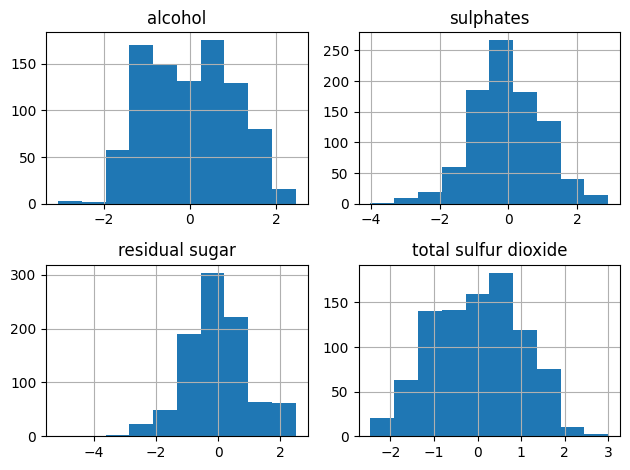

In [ ]:
#Histograma Datos Yeo
import matplotlib.pyplot as plt
import seaborn as sns
columnas = ['alcohol', 'sulphates', 'residual sugar', 'total sulfur dioxide']
X_train_yeojohnson_df[columnas].hist()

plt.tight_layout() # Evita que los títulos se superpongan
plt.show()

##Visualizacion

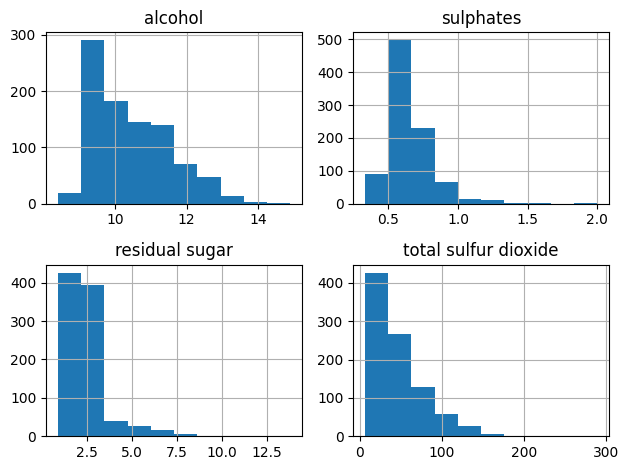

In [ ]:
#Histograma Datos Originales
import matplotlib.pyplot as plt
import seaborn as sns
columnas = ['alcohol', 'sulphates', 'residual sugar', 'total sulfur dioxide']
X_train_original[columnas].hist()

plt.tight_layout() # Evita que los títulos se superpongan
plt.show()

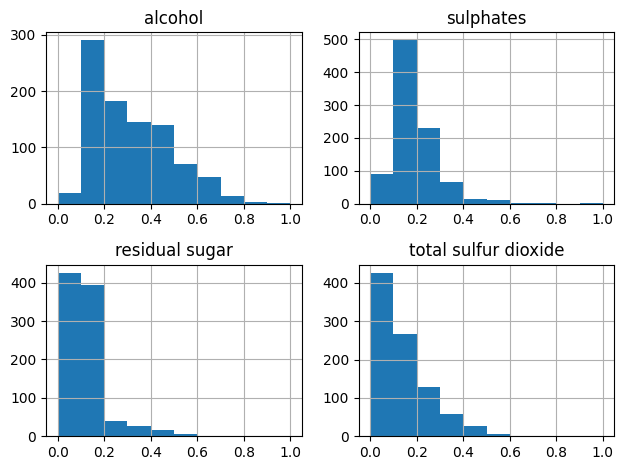

In [ ]:
#Histograma Datos Normalizados
import matplotlib.pyplot as plt
import seaborn as sns
columnas = ['alcohol', 'sulphates', 'residual sugar', 'total sulfur dioxide']
X_train_normalized_df[columnas].hist()

plt.tight_layout() # Evita que los títulos se superpongan
plt.show()

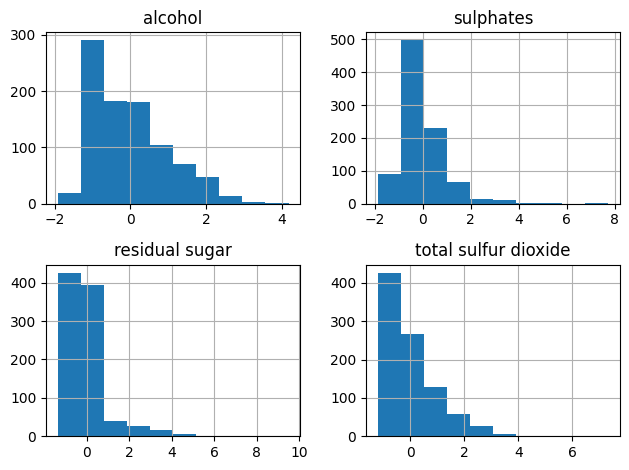

In [ ]:
#Histograma Datos Estandarizados
import matplotlib.pyplot as plt
import seaborn as sns
columnas = ['alcohol', 'sulphates', 'residual sugar', 'total sulfur dioxide']
X_train_standardized_df[columnas].hist()

plt.tight_layout() # Evita que los títulos se superpongan
plt.show()

In [ ]:
X_train_normalized_df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,914.000000,914.000000,914.000000,914.000000,914.000000,914.000000,914.000000,914.000000,914.000000,914.000000,914.000000
mean,0.329302,0.281208,0.271313,0.125155,0.125956,0.215593,0.140745,0.507382,0.448888,0.195797,0.315031
std,0.154513,0.122427,0.195437,0.092284,0.083676,0.149579,0.117173,0.145649,0.121328,0.104049,0.163855
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.221239,0.184932,0.100000,0.077519,0.096828,0.089552,0.053004,0.419078,0.370079,0.131737,0.169231
50%,0.292035,0.273973,0.255000,0.100775,0.111853,0.179104,0.109541,0.504950,0.448819,0.173653,0.276923
75%,0.398230,0.356164,0.420000,0.131783,0.130217,0.298507,0.194346,0.590442,0.519685,0.233533,0.415385
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
X_train_standardized_df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,9.140000e+02,9.140000e+02,9.140000e+02,9.140000e+02,9.140000e+02,9.140000e+02,9.140000e+02,9.140000e+02,9.140000e+02,9.140000e+02,9.140000e+02
mean,3.702363e-16,-8.259865e-17,1.826888e-16,9.134439e-17,1.554798e-17,3.498296e-17,-1.030054e-16,2.376703e-14,-1.341013e-16,1.875475e-16,-1.423612e-15
std,1.000547e+00,1.000547e+00,1.000547e+00,1.000547e+00,1.000547e+00,1.000547e+00,1.000547e+00,1.000547e+00,1.000547e+00,1.000547e+00,1.000547e+00
min,-2.132395e+00,-2.298208e+00,-1.389001e+00,-1.356932e+00,-1.506102e+00,-1.442126e+00,-1.201832e+00,-3.485494e+00,-3.701801e+00,-1.882800e+00,-1.923680e+00
25%,-6.997636e-01,-7.868311e-01,-8.770455e-01,-5.164646e-01,-3.482912e-01,-8.431017e-01,-7.492326e-01,-6.066070e-01,-6.499075e-01,-6.160081e-01,-8.903032e-01
50%,-2.413216e-01,-5.913099e-02,-8.351481e-02,-2.643243e-01,-1.686309e-01,-2.440773e-01,-2.664595e-01,-1.670335e-02,-5.683493e-04,-2.129379e-01,-2.326999e-01
75%,4.463415e-01,6.125922e-01,7.612114e-01,7.186274e-02,5.095400e-02,5.546219e-01,4.577002e-01,5.705843e-01,5.838369e-01,3.628765e-01,6.127901e-01
max,4.343099e+00,5.874424e+00,3.730552e+00,9.485100e+00,1.045129e+01,5.246980e+00,7.337217e+00,3.384072e+00,4.544806e+00,7.733301e+00,4.182637e+00


In [ ]:
X_train_yeojohnson_df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,9.140000e+02,9.140000e+02,9.140000e+02,9.140000e+02,9.140000e+02,9.140000e+02,9.140000e+02,9.140000e+02,9.140000e+02,9.140000e+02,9.140000e+02
mean,-2.030955e-15,-2.060107e-16,-1.826888e-16,-2.114525e-15,-1.195251e-15,3.381686e-16,5.305749e-16,3.018881e-11,-2.326367e-15,-6.413542e-17,-3.905125e-12
std,1.000547e+00,1.000547e+00,1.000547e+00,1.000547e+00,1.000547e+00,1.000547e+00,1.000547e+00,1.000547e+00,1.000547e+00,1.000547e+00,1.000547e+00
min,-3.515495e+00,-2.993987e+00,-1.550830e+00,-5.161852e+00,-6.243649e+00,-2.915315e+00,-2.452972e+00,-3.562536e+00,-3.908993e+00,-4.013333e+00,-3.054616e+00
25%,-6.748536e-01,-7.729591e-01,-8.684880e-01,-6.169035e-01,-4.783763e-01,-8.785459e-01,-7.714215e-01,-6.024640e-01,-6.416547e-01,-6.659605e-01,-9.532191e-01
50%,-9.272194e-02,4.201709e-02,2.685327e-02,-1.968543e-02,-3.604796e-03,1.040152e-02,2.897735e-02,-9.976923e-03,1.422269e-02,-3.125095e-02,-5.513951e-02
75%,6.131912e-01,6.911749e-01,8.177026e-01,5.515236e-01,4.852395e-01,7.582594e-01,7.447233e-01,5.752267e-01,5.938236e-01,6.646965e-01,7.846956e-01
max,2.766484e+00,3.853603e+00,2.787569e+00,2.502060e+00,2.989665e+00,2.775873e+00,2.993001e+00,3.315519e+00,4.282437e+00,2.906813e+00,2.448437e+00


**¿La forma de la distribución cambia?**

No, lo que cambia es la escala, al ser transformaciones lineales, comprime o estiira los datos, pero si teniamos en los datos sesgos a la derecha o izquierda, eso se va a mantener

**¿Qué ocurre con el rango de los valores?**

El rango disminuye.

**¿Qué ocurre con la media en cada caso?**

En el caso de la normalizacion, la media se mantiene entre el rango 0-1
En la estandarizacion, los datos se mantienen en un rango mas uniforme para que al modelo le se mas acertado leer los datos. Evitando que los datos con escalas mayores dominen el entrenamiento.

## Parte 4: Clasificacion con KNN

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


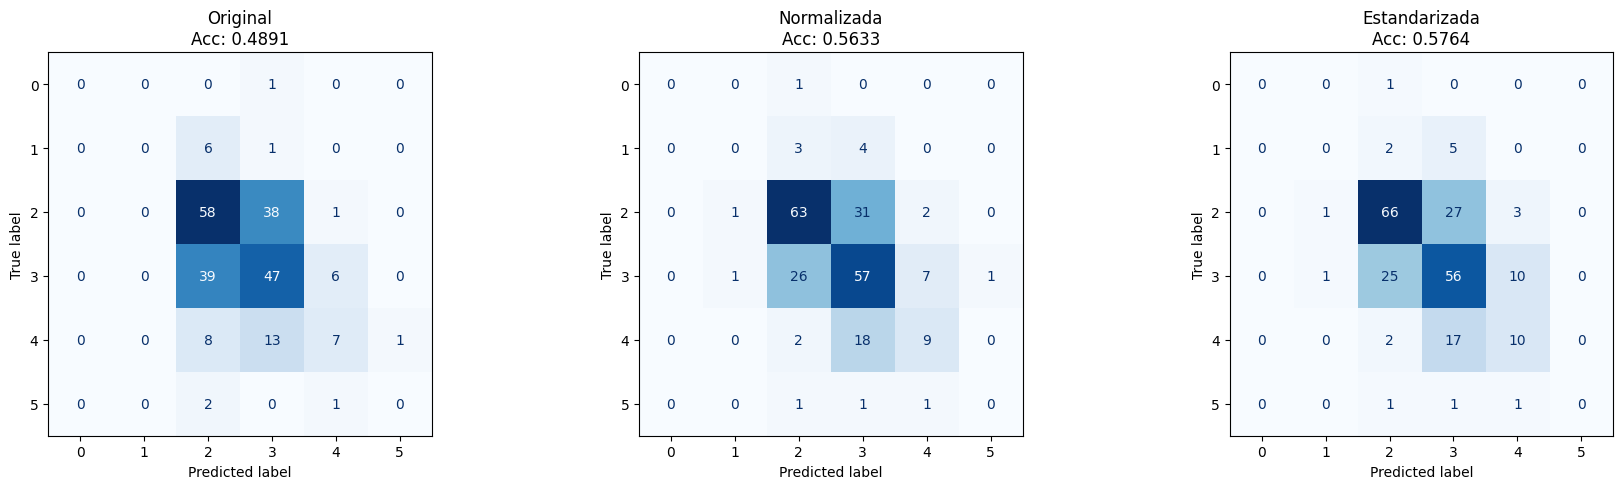

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

versiones = {
    'Original': (X_train_original, X_test_original),
    'Normalizada': (X_train_normalized_df, X_test_normalized),
    'Estandarizada': (X_train_standardized_df, X_test_standardized)
}

resultados = {}

# Paso 1: entrenar y calcular métricas para cada versión
for nombre, (X_tr, X_te) in versiones.items():
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_tr, y_train)
    y_pred = knn.predict(X_te)

    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    resultados[nombre] = {'accuracy': acc, 'confusion_matrix': cm}

# Paso 2: graficar usando lo que ya está en resultados
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nombre, datos) in zip(axes, resultados.items()):
    cm = datos['confusion_matrix']
    acc = datos['accuracy']

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
    ax.set_title(f"{nombre}\nAcc: {acc:.4f}")

plt.tight_layout()
plt.show()

¿Cuál obtuvo mejor desempeño?

La version estandarizada obtuvo el mejor rendimiento, tiene mejor datos en las diagonales.


¿Por qué KNN es sensible a la escala de los datos?

Porque basa sus predicciones en el cálculo de distancias (como la distancia euclidiana) para determinar qué puntos son similares. Si las características tienen rangos diferentes, la variable con mayor escala dominará el cálculo de la distancia, anulando el efecto de las demás



##Parte 5: Clasificacion con SVM

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


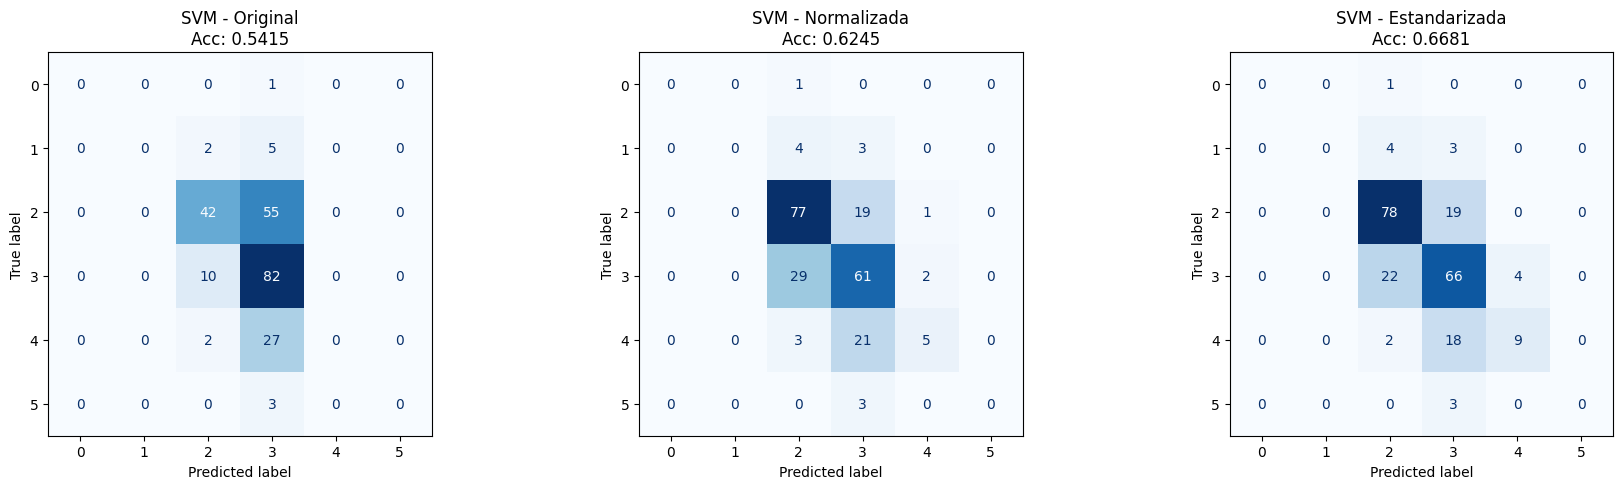

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

versiones = {
    'Original': (X_train_original, X_test_original),
    'Normalizada': (X_train_normalized_df, X_test_normalized),
    'Estandarizada': (X_train_standardized_df, X_test_standardized)
}

resultados_svm = {}

# Paso 1: entrenar y calcular métricas para cada versión
for nombre, (X_tr, X_te) in versiones.items():
    svm = SVC()
    svm.fit(X_tr, y_train)
    y_pred = svm.predict(X_te)

    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    resultados_svm[nombre] = {'accuracy': acc, 'confusion_matrix': cm}

# Paso 2: graficar las 3 matrices lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nombre, datos) in zip(axes, resultados_svm.items()):
    cm = datos['confusion_matrix']
    acc = datos['accuracy']

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
    ax.set_title(f"SVM - {nombre}\nAcc: {acc:.4f}")

plt.tight_layout()
plt.show()

¿Qué diferencias observa respecto a KNN?

Observo que con SVM obtuvo un mejor accuracy las tres versiones, tienen mejores predicciones y menos errores

¿Cuál técnica de escalado favoreció más a SVM?

A SVM lo favorecio mas la estandarizacion. Esto indica que transformar los datos para que tengan una media de cero y una desviación estándar de uno es la estrategia más beneficiosa para el SVM en este caso

##Parte 6: Pipeline

Accuracy: 0.6681

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.73      0.80      0.76        97
           6       0.61      0.72      0.66        92
           7       0.69      0.31      0.43        29
           8       0.00      0.00      0.00         3

    accuracy                           0.67       229
   macro avg       0.34      0.31      0.31       229
weighted avg       0.64      0.67      0.64       229



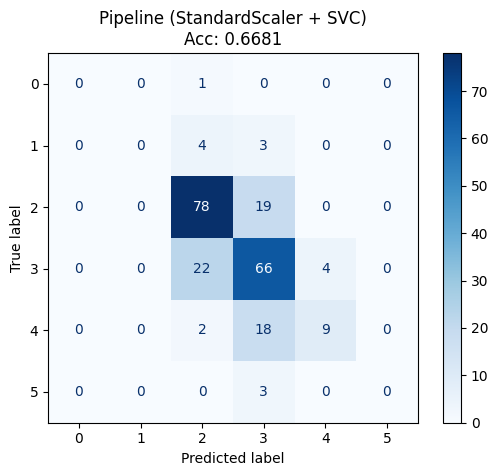

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# 1. Definir el pipeline
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC())
])

# 2. Entrenar el pipeline (el scaler se ajusta SOLO con X_train_original)
pipeline_svm.fit(X_train_original, y_train)

# 3. Predecir (el scaler aplica transform() con los parámetros aprendidos en train)
y_pred_pipeline = pipeline_svm.predict(X_test_original)

# 4. Evaluar
acc_pipeline = accuracy_score(y_test, y_pred_pipeline)
cm_pipeline = confusion_matrix(y_test, y_pred_pipeline)

print(f"Accuracy: {acc_pipeline:.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_pipeline, zero_division=0)}")

# 5. Graficar
disp = ConfusionMatrixDisplay(confusion_matrix=cm_pipeline)
disp.plot(cmap='Blues', values_format='d')
plt.title(f"Pipeline (StandardScaler + SVC)\nAcc: {acc_pipeline:.4f}")
plt.show()

##Conclusiones
Tanto para KNN como para SVM el escalado es crucial y mejora significativamente el rendimiento del modelo en comparacion con otras tecnicas o datos originales.
Pero el problema estructural persiste: ambos modelos son incapaces de detectar las clases 0, 1, 4 y 5 por el severo desbalance de clases — mejorar el accuracy general no resuelve ese problema de fondo, que necesitaría técnicas específicas de balanceo